In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
lal.swig_redirect_standard_output_error(False)
import lalsimulation as lalsim
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy import optimize as opt
from scipy.integrate import quad
from scipy.interpolate import interp1d
import matplotlib.ticker as ticker

from aquarel import load_theme

theme_dark = ( #theme_dark
        load_theme("gruvbox_dark")
        .set_font("serif")
        .set_grid(True, width=0.2)
        )

theme = (
        load_theme("scientific")
        .set_font("serif")
        .set_grid(True, width=0.2)
        .set_lines(width=2)
        .set_axes(top=True, right=True, width=1.5)
        .set_ticks(width_major=1.2, width_minor=0.9, size_major=11, size_minor=4, direction='in')
        .set_tick_labels(size="large") # large for single plot, xx-large for 2 subplots. need to change it in this line!!
        .set_overrides({
            "ytick.right": "true",
            "xtick.top": "true",
        })
        .set_title(pad=15)
        .set_axis_labels(weight="roman", size="x-large")
        .set_legend(text_size="large")
        )
theme.apply()
big_fontsize = 20


plot_dir = "/home/sam/thesis/writing/images/"

In [ ]:
def generate_waveform(lam1,lam2):
    """
    GW170817 params, tidal deformabilities set by user
    """
    sampling_frequency = 4096.0*1.5
    delta_t = 1.0 / sampling_frequency

    m1 = 1.4 * lal.MSUN_SI 
    m2 = 1.4 * lal.MSUN_SI 
    spin1x, spin1y, spin1z = (0.0, 0.0, 0.0)
    spin2x, spin2y, spin2z = (0.0, 0.0, 0.0)
    luminosity_distance = 40 * 1e6 * lal.PC_SI # arxiv.org/pdf/1710.05832
    inclination = 34.0 * np.pi / 180.0 # https://dcc.ligo.org/public/0150/P1800061/011/LVC_GW170817SourceProperties_PRX.pdf, viewing angle = min(theta_JN, 180 - theta_JN)
    phase = 0
    long_asc_nodes = 0.0
    eccentricity = 0.0
    mean_per_ano = 0.0

    LALParams = lal.CreateDict()
    lalsim.SimInspiralWaveformParamsInsertTidalLambda1(LALParams, lam1)
    lalsim.SimInspiralWaveformParamsInsertTidalLambda2(LALParams, lam2)

    waveform_approximant = "IMRPhenomXP_NRTidalv3"
    approximant = lalsim.GetApproximantFromString(waveform_approximant)

    f_ref = 20.0

    h_plus_timeseries, h_cross_timeseries = lalsim.SimInspiralChooseTDWaveform(
        m1, m2,
        spin1x, spin1y, spin1z,
        spin2x, spin2y, spin2z,
        luminosity_distance, inclination, phase, long_asc_nodes,
        eccentricity, mean_per_ano,
        delta_t, f_ref, f_ref, LALParams, approximant
        )


    h_plus = h_plus_timeseries.data.data
    h_cross = h_cross_timeseries.data.data
    h_plus_time = np.arange(len(h_plus)) * h_plus_timeseries.deltaT + float(h_plus_timeseries.epoch)
    h_cross_time = np.arange(len(h_cross)) * h_cross_timeseries.deltaT + float(h_cross_timeseries.epoch)

    detector_name = "H1"
    detector = lal.cached_detector_by_prefix["H1"]

    ra = 3.44626
    dec = -0.408084
    psi = 0.5 
    time_geocent = 1187008882.43

    Fp, Fc = lal.ComputeDetAMResponse(detector.response,
                                    ra, dec, psi,
                                    lal.GreenwichMeanSiderealTime(time_geocent))

    strain = Fp * h_plus + Fc * h_cross
    strain_time = h_plus_time

    return strain, strain_time


def alignintegrandTD(t, phi1, phi2, t0, phi0):
    return np.abs(phi1(t) - phi2(t+t0) - 2*phi0)**2

def minimiserTD(x, phi1, phi2, tmin, tmax):
    t0 = x[0]
    phi0 = x[1]
    return quad(alignintegrandTD, tmin, tmax, args = (phi1, phi2, t0, phi0))[0]

def alignTD(t1, t2,phi1,phi2,tmin,tmax):
    phi_TEOB_func = interp1d(t1,phi1)
    phi_F2_func = interp1d(t2,phi2)
    res = opt.minimize(minimiserTD, x0 = np.asarray([0.,0.]), args = (phi_TEOB_func, phi_F2_func, tmin, tmax), bounds=[[-186,0.0038],[-10**5,10**5]])

    t0 = res.x[0]
    phi0 = res.x[1]

    return [t0,phi0]

def get_phase(signal):
    analytic_signal = hilbert(signal)
    phase = np.angle(analytic_signal)
    return np.unwrap(phase)

In [3]:
strain_bbh, strain_time_bbh = generate_waveform(0.0, 0.0)
strain_bns, strain_time_bns = generate_waveform(400.0, 400.0)

phase_bbh = get_phase(strain_bbh)
phase_bns = get_phase(strain_bns)

t0, phi0 = alignTD(strain_time_bbh, strain_time_bns, phase_bbh, phase_bns, tmin=-0.01, tmax=-0.009)

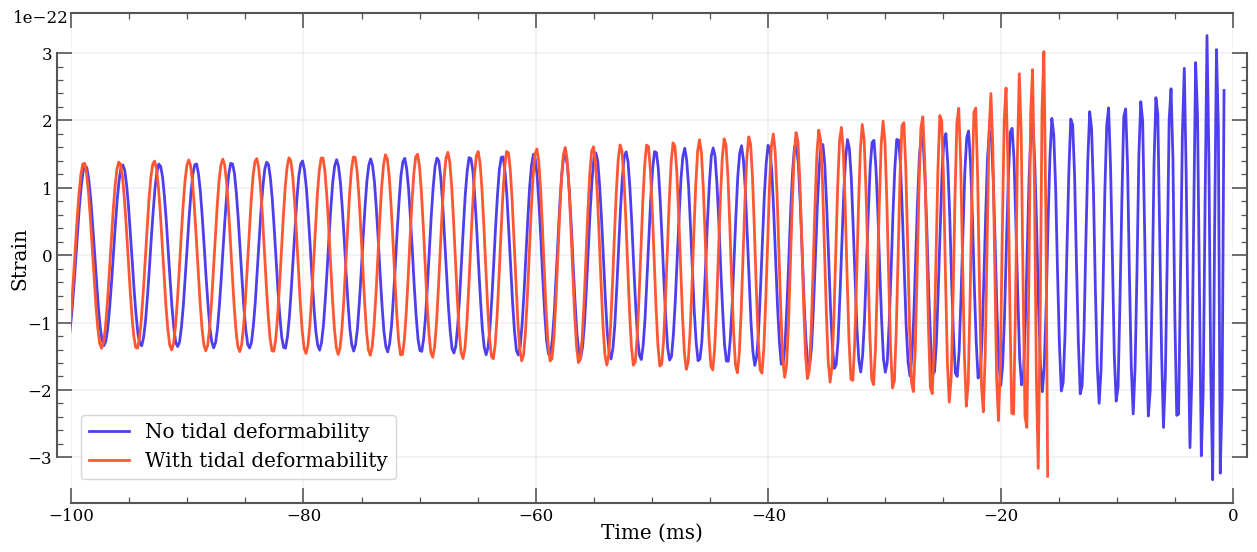

In [ ]:
skip_merger = 30

plt.figure(figsize=(15,6))
plt.plot(strain_time_bbh[:-skip_merger] * 1e3, strain_bbh[:-skip_merger], label="No tidal deformability", color="#4e3fee")
plt.plot((strain_time_bns[:-skip_merger] + t0)* 1e3, strain_bns[:-skip_merger], label="With tidal deformability", color="#ff5733")
plt.xlabel("Time (ms)")
plt.ylabel("Strain")
plt.xlim(-0.1 * 1e3, 0.)
plt.legend(loc="lower left", fontsize="x-large")
plt.title('')
ax = plt.gca()
ax.yaxis.get_offset_text().set_position((-0.05, 1.0))
theme.apply_transforms()
#plt.savefig(plot_dir + "waveform.png", dpi=300)
plt.show()